# MScFE 690 Capstone: XGBoost Return Forecasting and Portfolio Construction


# XGBoost Return Forecasting and Portfolio Construction

This notebook implements an XGBoost-based framework for forecasting five-trading-day ETF returns and converting those forecasts into portfolio weights. The analysis uses eight ETFs: SPY, EFA, EEM, IEF, TLT, LQD, GLD, and DBC, with daily data from 2010 to 2025.

## Methodology

The data are processed on a common trading-date index. Adjusted closing prices are used to calculate returns, while trading volume is used as a predictor. The forecasting target for asset $i$ at date $t$ is the five-trading-day forward return:

$$
R_{i,t}^{(5)} = \frac{P_{i,t+5}}{P_{i,t}} - 1 .
$$

The model uses five predictors, where $P_{i,t}$ is the adjusted close, $V_{i,t}$ is the trading volume and $r_{i,t} = P_{i,t}/P_{i,t-1} - 1$ is the daily simple return of asset $i$:

1. Five-day lagged return:
   $$x_{i,t}^{(1)} = \frac{P_{i,t}}{P_{i,t-5}} - 1$$
2. Twenty-day lagged return:
   $$x_{i,t}^{(2)} = \frac{P_{i,t}}{P_{i,t-20}} - 1$$
3. Twenty-day realised volatility (sample standard deviation of daily returns):
   $$x_{i,t}^{(3)} = \sqrt{\frac{1}{19}\sum_{j=0}^{19}\left(r_{i,t-j} - \bar{r}_{i,t}\right)^2}, \qquad \bar{r}_{i,t} = \frac{1}{20}\sum_{j=0}^{19} r_{i,t-j}$$
4. Price deviation from the twenty-day moving average:
   $$x_{i,t}^{(4)} = \frac{P_{i,t}}{\frac{1}{20}\sum_{j=0}^{19} P_{i,t-j}} - 1$$
5. Five-day percentage change in trading volume:
   $$x_{i,t}^{(5)} = \frac{V_{i,t}}{V_{i,t-5}} - 1$$

All predictors are constructed from information available at the prediction date. The features are lagged so that future observations cannot enter the model inputs.

A separate XGBoost regression model $f_i(\cdot)$ is estimated for each ETF, so that the forecast is

$$
\hat{R}_{i,t}^{(5)} = f_i\!\left(x_{i,t}^{(1)}, x_{i,t}^{(2)}, x_{i,t}^{(3)}, x_{i,t}^{(4)}, x_{i,t}^{(5)}\right).
$$

The models use the same five predictors but are fitted independently by asset. The model is trained chronologically splits. The sample is divided into training, validation, and out-of-sample test periods, with the test period reserved for the final walk-forward evaluation.

The weekly forecasting procedure maps each rebalance date to the most recent available trading date. This prevents market holidays from creating invalid date lookups. Before each forecast, observations whose five-day forward targets could overlap the decision date are excluded. The model is then fitted using only information available before the decision date and produces a five-day return forecast for each ETF.

Forecast accuracy is evaluated over the $N$ out-of-sample forecasts using RMSE, MAE, and the correlation between predicted and realised five-day returns:

$$
\text{RMSE} = \sqrt{\frac{1}{N}\sum_{k=1}^{N}\left(R_k - \hat{R}_k\right)^2}, \qquad
\text{MAE} = \frac{1}{N}\sum_{k=1}^{N}\left|R_k - \hat{R}_k\right|, \qquad
\rho = \operatorname{Corr}\!\left(R, \hat{R}\right).
$$

The portfolio uses the XGBoost forecasts as the expected-return vector $\mu_t$ and a trailing covariance matrix $\Sigma_t$ estimated from daily returns as the risk input. Portfolio weights are obtained from a constrained mean-variance objective:

$$
\max_{w} \quad \mu_t^{\top} w - \lambda\, w^{\top} \Sigma_t w
$$

subject to

$$
\sum_{i} w_i = 1, \qquad 0 \leq w_i \leq 0.30 .
$$

The portfolio is therefore fully invested, long-only, and subject to a 30% maximum weight per ETF. The covariance matrix is estimated from the trailing 252-day daily return history and scaled to the same five-trading-day horizon as the return forecast $\mu_t$, so that the return and risk terms of the objective are on a consistent time scale:

$$
\Sigma_t = 5 \cdot \widehat{\operatorname{Cov}}\left(r_{t-251}, \ldots, r_{t}\right).
$$



Portfolio performance is evaluated out of sample using the returns following each weekly allocation decision, $r_{p,t+1} = w_t^{\top} r_{t+1}$, where $r_{t+1}$ is the vector of next-week ETF returns. The notebook reports the following metrics for the $T$ weekly portfolio returns (52 periods per year):

$$
\text{Ann. Return} = \left[\prod_{t=1}^{T}\left(1 + r_{p,t}\right)\right]^{52/T} - 1, \qquad
\text{Ann. Volatility} = \sigma_p \sqrt{52},
$$

$$
\text{Sharpe} = \frac{\text{Ann. Return}}{\text{Ann. Volatility}}, \qquad
\text{Sortino} = \frac{\text{Ann. Return}}{\sigma_p^{-}\sqrt{52}},
$$

where $\sigma_p$ is the sample standard deviation of weekly portfolio returns and $\sigma_p^{-}$ is the sample standard deviation of the negative weekly returns only. Maximum drawdown and historical 95% CVaR are

$$
\text{MaxDD} = \min_{t}\left(\frac{W_t}{\max_{s \leq t} W_s} - 1\right), \qquad
W_t = \prod_{s=1}^{t}\left(1 + r_{p,s}\right),
$$

$$
\text{CVaR}_{95\%} = \mathbb{E}\left[\,L \mid L \geq \operatorname{VaR}_{95\%}(L)\,\right], \qquad L = -r_p .
$$

It also produces plots of cumulative portfolio performance, drawdowns, forecast accuracy by asset, and portfolio weights through time.

The XGBoost portfolio is benchmarked against three portfolios that use no machine-learning forecasts. They share the same constraints and are evaluated on the same weekly decision dates, so the comparison is made over an identical out-of-sample window. Each is estimated from the trailing 252-day covariance matrix $\Sigma_t$ and volatilities $\sigma_{i,t} = \sqrt{\Sigma_{t,ii}}$:

$$
\text{Equal Weight:}\quad w_i = \frac{1}{N}, \qquad
\text{Mean-Variance:}\quad \min_{w}\; w^{\top}\Sigma_t\, w, \qquad
\text{Risk Parity:}\quad w_i = \frac{1/\sigma_{i,t}}{\sum_{j} 1/\sigma_{j,t}},
$$

where $N = 8$ ETFs, and the Mean-Variance and Risk-Parity weights are subject to the same constraints $\sum_i w_i = 1$ and $0 \leq w_i \leq 0.30$. The Mean-Variance benchmark is the long-only minimum-variance portfolio. The Risk-Parity weights are capped at 30%. All four portfolios are compared using the same performance metrics, cumulative performance, and drawdowns.

The empirical pipeline is:

$$
\begin{aligned}
&\text{Market Data} \rightarrow \text{Feature Construction} \rightarrow \text{XGBoost Forecasts} \\
&\quad \rightarrow \text{Walk-Forward Testing} \rightarrow \text{Portfolio Optimisation} \rightarrow \text{Out-of-Sample Evaluation} \rightarrow \text{Benchmark Comparison}.
\end{aligned}
$$

In [ ]:

%pip install yfinance==1.2.0 cvxpy openpyxl xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 100.4 MB/s eta 0:00:00
  Attempting uninstall: curl_cffi
    Found existing installation: curl_cffi 0.16.2
    Uninstalling curl_cffi-0.16.2:
      Successfully uninstalled curl_cffi-0.16.2
  Attempting uninstall: yfinance
    Found existing installation: yfinance 0.2.66
    Uninstalling yfinance-0.2.66:
      Successfully uninstalled yfinance-0.2.66


In [ ]:
import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 1. Configuration

Yahoo Finance treats the `end` date as exclusive, so `2026-01-01` is used to include observations through `2025-12-31`.


In [ ]:
TICKERS = ["SPY", "EFA", "EEM", "IEF", "TLT", "LQD", "GLD", "DBC"]

START_DATE = "2010-01-01"
END_DATE = "2026-01-01"

TRAIN_END = "2016-12-31"
VALID_START = "2017-01-01"
VALID_END = "2018-12-31"
TEST_START = "2019-01-01"

MAX_WEIGHT = 0.30
LOOKBACK_DAYS = 252
WEEKLY_RULE = "W-FRI"

BASE = Path(".")
for p in [
    BASE / "data" / "raw",
    BASE / "data" / "processed",
    BASE / "data" / "validation",
    BASE / "outputs" / "benchmarks",
    BASE / "outputs" / "figures",
]:
    p.mkdir(parents=True, exist_ok=True)

print("Folders ready.")


Folders ready.


## 2. Download Daily Yahoo Finance Data


In [ ]:
raw = yf.download(
    TICKERS,
    start=START_DATE,
    end=END_DATE,
    progress=False,
    auto_adjust=False,
    threads=False,
)[["Adj Close", "Volume"]]

print("Raw shape:", raw.shape)
display(raw.head())

Raw shape: (4024, 16)


Price       Adj Close                                                                                 Volume                      \
Ticker            DBC        EEM        EFA         GLD        IEF        LQD        SPY        TLT      DBC       EEM       EFA   
Date                                                                                                                               
2010-01-04  21.338846  30.194571  34.581203  109.800003  60.713726  56.746056  84.368973  55.070801  2046900  70761600  18556900   
2010-01-05  21.364210  30.413727  34.611698  109.699997  60.980309  57.017059  84.592300  55.426418  2335400  50196300  14352800   
2010-01-06  21.744654  30.477348  34.757984  111.510002  60.734173  56.848991  84.651863  54.684505  2262600  50670000  11888100   
2010-01-07  21.474115  30.300610  34.623871  110.820000  60.734173  56.919506  85.009224  54.776489  1604100  41803700  10906600   
2010-01-08  21.457207  30.540989  34.898186  111.370003  60.809399  57.044174  85.292061  54.751976  1565300  41118100  12826500   

Price                                                       
Ticker           GLD      IEF      LQD        SPY      TLT  
Date                                                        
2010-01-04  16224100   619100  2017600  118944600  2829100  
2010-01-05  14213100  1547500  1143800  111579900  2841600  
2010-01-06  24981900   365500  1005500  116074400  4099600  
2010-01-07  13609800   390900  1264100  131091100  2793200  
2010-01-08  15894600   382500   704600  126402800  2910700

In [ ]:
# Save raw download
raw.to_csv(BASE / "data" / "raw" / "yahoo_etf_raw.csv")
print("Saved raw Yahoo Finance data.")


Saved raw Yahoo Finance data.


## 3. Extract Adjusted Close Prices and Volume

Adjusted close prices are used for return calculations because they account for distributions and corporate actions. Trading volume is retained for the machine-learning feature set.


In [ ]:
adjusted_close = raw["Adj Close"].reindex(columns=TICKERS).sort_index()
adjusted_close.index = pd.to_datetime(adjusted_close.index)

display(adjusted_close.head())
print(adjusted_close.shape)

Ticker,SPY,EFA,EEM,IEF,TLT,LQD,GLD,DBC
Date,,,,,,,,
2010-01-04,84.368973,34.581203,30.194571,60.713726,55.070801,56.746056,109.800003,21.338846
2010-01-05,84.592300,34.611698,30.413727,60.980309,55.426418,57.017059,109.699997,21.364210
2010-01-06,84.651863,34.757984,30.477348,60.734173,54.684505,56.848991,111.510002,21.744654
2010-01-07,85.009224,34.623871,30.300610,60.734173,54.776489,56.919506,110.820000,21.474115
2010-01-08,85.292061,34.898186,30.540989,60.809399,54.751976,57.044174,111.370003,21.457207


(4024, 8)


In [ ]:
# Extract trading volume for ML features
volume = raw["Volume"].reindex(columns=TICKERS).sort_index()
volume.index = pd.to_datetime(volume.index)
volume = volume.reindex(adjusted_close.index)

display(volume.head())

Ticker,SPY,EFA,EEM,IEF,TLT,LQD,GLD,DBC
Date,,,,,,,,
2010-01-04,118944600,18556900,70761600,619100,2829100,2017600,16224100,2046900
2010-01-05,111579900,14352800,50196300,1547500,2841600,1143800,14213100,2335400
2010-01-06,116074400,11888100,50670000,365500,4099600,1005500,24981900,2262600
2010-01-07,131091100,10906600,41803700,390900,2793200,1264100,13609800,1604100
2010-01-08,126402800,12826500,41118100,382500,2910700,704600,15894600,1565300


## 4. Data Validation

The checks below cover:
- first and last valid observation
- observation counts
- missing values
- duplicate dates
- non-positive adjusted prices
- suspiciously large daily returns


In [ ]:
validation_rows = []

for ticker in TICKERS:
    s = adjusted_close[ticker]

    validation_rows.append({
        "Ticker": ticker,
        "First_Valid_Date": s.first_valid_index(),
        "Last_Valid_Date": s.last_valid_index(),
        "Observations": int(s.notna().sum()),
        "Missing_Values": int(s.isna().sum()),
        "Non_Positive_Prices": int((s.dropna() <= 0).sum()),
    })

quality_report = pd.DataFrame(validation_rows)

duplicate_dates = int(adjusted_close.index.duplicated().sum())

print("Duplicate dates in index:", duplicate_dates)
display(quality_report)


Duplicate dates in index: 0


,Ticker,First_Valid_Date,Last_Valid_Date,Observations,Missing_Values,Non_Positive_Prices
0,SPY,2010-01-04,2025-12-31,4024,0,0
1,EFA,2010-01-04,2025-12-31,4024,0,0
2,EEM,2010-01-04,2025-12-31,4024,0,0
3,IEF,2010-01-04,2025-12-31,4024,0,0
4,TLT,2010-01-04,2025-12-31,4024,0,0
5,LQD,2010-01-04,2025-12-31,4024,0,0
6,GLD,2010-01-04,2025-12-31,4024,0,0
7,DBC,2010-01-04,2025-12-31,4024,0,0


In [ ]:
# Daily returns used only for diagnostic validation at this stage
diagnostic_returns = adjusted_close.pct_change(fill_method=None)

extreme_return_report = pd.DataFrame({
    "Min_Daily_Return": diagnostic_returns.min(),
    "Max_Daily_Return": diagnostic_returns.max(),
    "Abs_Return_Above_20pct": (diagnostic_returns.abs() > 0.20).sum()
}).reset_index().rename(columns={"index": "Ticker"})

quality_report = quality_report.merge(extreme_return_report, on="Ticker", how="left")
quality_report["Duplicate_Dates_In_Index"] = duplicate_dates

display(quality_report)
quality_report.to_csv(BASE / "data" / "validation" / "data_quality_report.csv", index=False)


,Ticker,First_Valid_Date,Last_Valid_Date,Observations,Missing_Values,Non_Positive_Prices,Min_Daily_Return,Max_Daily_Return,Abs_Return_Above_20pct,Duplicate_Dates_In_Index
0,SPY,2010-01-04,2025-12-31,4024,0,0,-0.109424,0.105019,0,0
1,EFA,2010-01-04,2025-12-31,4024,0,0,-0.109902,0.084731,0,0
2,EEM,2010-01-04,2025-12-31,4024,0,0,-0.124792,0.080529,0,0
3,IEF,2010-01-04,2025-12-31,4024,0,0,-0.025073,0.026417,0,0
4,TLT,2010-01-04,2025-12-31,4024,0,0,-0.066683,0.075196,0,0
5,LQD,2010-01-04,2025-12-31,4024,0,0,-0.050030,0.073918,0,0
6,GLD,2010-01-04,2025-12-31,4024,0,0,-0.087808,0.049038,0,0
7,DBC,2010-01-04,2025-12-31,4024,0,0,-0.079444,0.047990,0,0


## 5. Align the Investment Universe

For the core modelling dataset, We used only dates where all eight ETFs have valid adjusted prices. Volume is aligned to the same dates for feature construction.

This avoids artificial zero-filling and ensures every portfolio decision is based on a common cross-section.


In [ ]:
prices_aligned = adjusted_close.dropna(how="any").copy()
volume_aligned = volume.reindex(prices_aligned.index).copy()

print("Before alignment:", adjusted_close.shape)
print("After alignment :", prices_aligned.shape)
print("Start:", prices_aligned.index.min())
print("End  :", prices_aligned.index.max())

prices_aligned.to_csv(BASE / "data" / "processed" / "adjusted_close.csv")
volume_aligned.to_csv(BASE / "data" / "processed" / "volume.csv")


Before alignment: (4024, 8)
After alignment : (4024, 8)
Start: 2010-01-04 00:00:00
End  : 2025-12-31 00:00:00


## 6. Daily Simple Returns and Log Returns


In [ ]:
daily_returns = prices_aligned.pct_change(fill_method=None).dropna()
log_returns = np.log(prices_aligned / prices_aligned.shift(1)).dropna()

daily_returns.to_csv(BASE / "data" / "processed" / "daily_returns.csv")
log_returns.to_csv(BASE / "data" / "processed" / "log_returns.csv")

display(daily_returns.head())


Ticker,SPY,EFA,EEM,IEF,TLT,LQD,GLD,DBC
Date,,,,,,,,
2010-01-05,0.002647,0.000882,0.007258,0.004391,0.006457,0.004776,-0.000911,0.001189
2010-01-06,0.000704,0.004226,0.002092,-0.004036,-0.013386,-0.002948,0.016500,0.017808
2010-01-07,0.004222,-0.003858,-0.005799,0.000000,0.001682,0.001240,-0.006188,-0.012442
2010-01-08,0.003327,0.007923,0.007933,0.001239,-0.000448,0.002190,0.004963,-0.000787
2010-01-11,0.001397,0.008209,-0.002084,0.000674,-0.005488,0.001045,0.013289,-0.003152


## 7. Five-Trading-Day Forward Return Target

For asset $i$ at time $t$:

$$
R_{i,t \rightarrow t+5} = \frac{P_{i,t+5}}{P_{i,t}} - 1
$$

This is a **forward-looking target**


In [ ]:
forward_5d_returns = prices_aligned.shift(-5) / prices_aligned - 1
forward_5d_returns.to_csv(BASE / "data" / "processed" / "forward_5d_returns.csv")

display(forward_5d_returns.head())


Ticker,SPY,EFA,EEM,IEF,TLT,LQD,GLD,DBC
Date,,,,,,,,
2010-01-04,0.012353,0.017451,0.009365,0.002251,-0.011245,0.006304,0.027778,0.002377
2010-01-05,0.000264,0.004579,-0.013947,0.005044,-0.000773,0.003422,0.007201,-0.020182
2010-01-06,0.008003,0.008769,-0.012990,0.004278,0.001009,0.002193,0.000269,-0.036547
2010-01-07,0.006480,0.020423,-0.009799,0.009004,0.013321,0.004571,0.010919,-0.029528
2010-01-08,-0.008117,-0.003493,-0.028935,0.012253,0.020047,0.001995,-0.004579,-0.039795


## 8. Research Period Labels


In [ ]:
calendar = pd.DataFrame(index=prices_aligned.index)

calendar["Period"] = np.select(
    [
        calendar.index <= pd.Timestamp(TRAIN_END),
        (calendar.index >= pd.Timestamp(VALID_START)) & (calendar.index <= pd.Timestamp(VALID_END)),
        calendar.index >= pd.Timestamp(TEST_START),
    ],
    ["Train", "Validation", "Test"],
    default="Outside"
)

display(calendar["Period"].value_counts())


,count
Period,
Train,1762
Test,1760
Validation,502


## 9. Five-Trading-Day Purge at Sample Boundaries

Because the target uses the next five trading days, the last five trading observations immediately before the validation and test periods are flagged for exclusion from model fitting.


In [ ]:
calendar["Purged"] = False

valid_start_actual = calendar.index[calendar.index >= pd.Timestamp(VALID_START)][0]
test_start_actual = calendar.index[calendar.index >= pd.Timestamp(TEST_START)][0]

before_valid = calendar.index[calendar.index < valid_start_actual][-5:]
before_test = calendar.index[calendar.index < test_start_actual][-5:]

calendar.loc[before_valid, "Purged"] = True
calendar.loc[before_test, "Purged"] = True

calendar["Usable_For_Model"] = ~calendar["Purged"]

print("Validation starts:", valid_start_actual)
print("Test starts      :", test_start_actual)
print("\nPurged before validation:")
print(before_valid)
print("\nPurged before test:")
print(before_test)

calendar.to_csv(BASE / "data" / "processed" / "modelling_calendar.csv")


Validation starts: 2017-01-03 00:00:00
Test starts      : 2019-01-02 00:00:00

Purged before validation:
DatetimeIndex(['2016-12-23', '2016-12-27', '2016-12-28', '2016-12-29', '2016-12-30'], dtype='datetime64[ns]', name='Date', freq=None)

Purged before test:
DatetimeIndex(['2018-12-24', '2018-12-26', '2018-12-27', '2018-12-28', '2018-12-31'], dtype='datetime64[ns]', name='Date', freq=None)


# 10. Feature Construction for XGBoost

For each asset, the model uses five predictors: 5-day return, 20-day return, 20-day realised volatility, price relative to its 20-day moving average, and 5-day percentage change in trading volume:

$$
x_{i,t}^{(1)} = \frac{P_{i,t}}{P_{i,t-5}} - 1, \qquad
x_{i,t}^{(2)} = \frac{P_{i,t}}{P_{i,t-20}} - 1, \qquad
x_{i,t}^{(3)} = \operatorname{std}\left(r_{i,t-19}, \ldots, r_{i,t}\right),
$$

$$
x_{i,t}^{(4)} = \frac{P_{i,t}}{\operatorname{MA}_{20}(P_{i,t})} - 1, \qquad
x_{i,t}^{(5)} = \frac{V_{i,t}}{V_{i,t-5}} - 1 .
$$

All features are calculated using information available at the decision date. The target is the next five-trading-day return defined earlier.

In [ ]:
FEATURE_NAMES = [
    "Return_5D",
    "Return_20D",
    "Volatility_20D",
    "Price_MA20_Gap",
    "Volume_Change_5D",
]

def build_features(prices, volume):
    daily_ret = prices.pct_change(fill_method=None)

    features = {}
    for ticker in TICKERS:
        p = prices[ticker]
        v = volume[ticker]
        r = daily_ret[ticker]

        ticker_features = pd.DataFrame(index=prices.index)
        ticker_features["Return_5D"] = p.pct_change(5)
        ticker_features["Return_20D"] = p.pct_change(20)
        ticker_features["Volatility_20D"] = r.rolling(20).std()
        ticker_features["Price_MA20_Gap"] = p / p.rolling(20).mean() - 1
        ticker_features["Volume_Change_5D"] = v.pct_change(5).replace([np.inf, -np.inf], np.nan)

        features[ticker] = ticker_features

    return features

feature_data = build_features(prices_aligned, volume_aligned)

display(feature_data["SPY"].head(25))


,Return_5D,Return_20D,Volatility_20D,Price_MA20_Gap,Volume_Change_5D
Date,,,,,
2010-01-04,NaN,NaN,NaN,NaN,NaN
2010-01-05,NaN,NaN,NaN,NaN,NaN
2010-01-06,NaN,NaN,NaN,NaN,NaN
2010-01-07,NaN,NaN,NaN,NaN,NaN
2010-01-08,NaN,NaN,NaN,NaN,NaN
2010-01-11,0.012353,NaN,NaN,NaN,-0.105670
2010-01-12,0.000264,NaN,NaN,NaN,0.463825
2010-01-13,0.008003,NaN,NaN,NaN,0.394123
2010-01-14,0.006480,NaN,NaN,NaN,-0.117264


## 10.1 Build Asset-Level Modelling Dataset



In [ ]:
model_data = {}

for ticker in TICKERS:
    df = feature_data[ticker].copy()
    df["Target"] = forward_5d_returns[ticker]
    df["Period"] = calendar["Period"]
    df["Purged"] = calendar["Purged"]
    df = df.dropna(subset=FEATURE_NAMES + ["Target"])
    model_data[ticker] = df

print("Example modelling dataset:")
display(model_data["SPY"].head())
print("SPY observations:", len(model_data["SPY"]))


Example modelling dataset:


,Return_5D,Return_20D,Volatility_20D,Price_MA20_Gap,Volume_Change_5D,Target,Period,Purged
Date,,,,,,,,
2010-02-02,0.009789,-0.026030,0.010585,-0.015278,0.024431,-0.028628,Train,False
2010-02-03,0.000000,-0.033442,0.010574,-0.018521,-0.364642,-0.025676,Train,False
2010-02-04,-0.019619,-0.063935,0.012403,-0.045715,0.128476,0.015877,Train,False
2010-02-05,-0.006798,-0.065943,0.012344,-0.040504,0.588740,0.012939,Train,False
2010-02-08,-0.029067,-0.075761,0.012270,-0.043697,0.193234,0.036359,Train,False


SPY observations: 3999


## 10.2 XGBoost Model Configuration


In [ ]:
def make_xgb_model():
    return XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.80,
        colsample_bytree=0.80,
        min_child_weight=5,
        reg_alpha=0.10,
        reg_lambda=1.00,
        random_state=42,
        n_jobs=-1,
    )

## 10.3 Validation Performance

Model selection is performed using the chronological training and validation periods. The test period is not used for parameter selection.

In [ ]:
validation_results = []
validation_models = {}

for ticker in TICKERS:
    df = model_data[ticker]

    train = df[(df["Period"] == "Train") & (~df["Purged"])]
    valid = df[(df["Period"] == "Validation") & (~df["Purged"])]

    model = make_xgb_model()
    model.fit(train[FEATURE_NAMES], train["Target"], verbose=False)

    pred = model.predict(valid[FEATURE_NAMES])
    actual = valid["Target"].values

    rmse = np.sqrt(np.mean((actual - pred) ** 2))
    mae = np.mean(np.abs(actual - pred))
    corr = np.corrcoef(actual, pred)[0, 1] if len(valid) > 1 else np.nan

    validation_results.append({
        "Ticker": ticker,
        "Validation_RMSE": rmse,
        "Validation_MAE": mae,
        "Validation_Correlation": corr,
    })
    validation_models[ticker] = model

validation_metrics = pd.DataFrame(validation_results).set_index("Ticker")
display(validation_metrics)

validation_metrics.to_csv(
    BASE / "outputs" / "benchmarks" / "xgb_validation_metrics.csv"
)


,Validation_RMSE,Validation_MAE,Validation_Correlation
Ticker,,,
SPY,0.019648,0.013203,-0.143715
EFA,0.016651,0.012670,0.065871
EEM,0.023190,0.018032,0.176140
IEF,0.005870,0.004698,0.118772
TLT,0.013410,0.010952,0.015337
LQD,0.005981,0.004751,-0.034962
GLD,0.016460,0.013428,0.070439
DBC,0.020429,0.016446,-0.053893


## 11. Weekly Portfolio Rebalance Dataset

The underlying information remains daily, but portfolio decisions are made weekly. This dataset is constructed before the XGBoost walk-forward forecast because the weekly rebalance dates define the forecast and portfolio evaluation dates.


In [ ]:
weekly_prices = prices_aligned.resample(WEEKLY_RULE).last().dropna()
weekly_returns = weekly_prices.pct_change(fill_method=None).dropna()

weekly_prices.to_csv(BASE / "data" / "processed" / "weekly_prices.csv")
weekly_returns.to_csv(BASE / "data" / "processed" / "weekly_returns.csv")

print("Weekly prices:", weekly_prices.shape)
display(weekly_prices.head())


Weekly prices: (835, 8)


Ticker,SPY,EFA,EEM,IEF,TLT,LQD,GLD,DBC
Date,,,,,,,,
2010-01-08,85.292061,34.898186,30.540989,60.809399,54.751976,57.044174,111.370003,21.457207
2010-01-15,84.599762,34.776276,29.657274,61.554478,55.849571,57.157955,110.860001,20.603313
2010-01-22,81.301834,32.837822,28.002962,61.937252,56.413704,57.233818,107.169998,19.884691
2010-01-29,79.946930,31.990517,27.062702,61.998791,56.603767,57.152527,105.959999,19.182980
2010-02-05,79.403450,31.380939,26.299171,62.300571,56.600700,56.837959,104.680000,18.920893


# 12. Walk-Forward XGBoost Return Forecasts

For each weekly portfolio decision date in the test period, each asset model is re-estimated using only information available before that date. The model is trained on all usable observations from the training and validation periods plus observations that have become available before the current test decision date. The following week's return is then evaluated out of sample.


In [ ]:
# Test-period weekly decision dates; each is paired with the next weekly date 
test_dates = weekly_prices.index[weekly_prices.index >= pd.Timestamp(TEST_START)]
trading_dates = prices_aligned.index

xgb_forecasts = pd.DataFrame(
    np.nan, columns=TICKERS, index=pd.Index(test_dates[:-1], name="Decision_Date")
)
xgb_actual_returns = xgb_forecasts.copy()
metadata_rows = []

for decision_date, return_date in zip(test_dates[:-1], test_dates[1:]):
    # Latest actual trading date on or before the weekly decision date
    position = trading_dates.searchsorted(decision_date, side="right") - 1
    feature_date = trading_dates[position]

    # Purge the five trading days immediately before the information date
    train_end_date = trading_dates[position - 5]

    for ticker in TICKERS:
        df = model_data[ticker]
        train_df = df[(df.index <= train_end_date) & ~df["Purged"] & df["Target"].notna()]

        if len(train_df) < 250:
            continue

        model = make_xgb_model()
        model.fit(train_df[FEATURE_NAMES], train_df["Target"], verbose=False)

        feature_row = feature_data[ticker].loc[[feature_date], FEATURE_NAMES]
        xgb_forecasts.loc[decision_date, ticker] = float(model.predict(feature_row)[0])
        xgb_actual_returns.loc[decision_date, ticker] = forward_5d_returns.loc[feature_date, ticker]

    metadata_rows.append((decision_date, feature_date, return_date))

# Metadata is kept separate so it can never enter portfolio optimisation
xgb_forecast_metadata = pd.DataFrame(
    metadata_rows, columns=["Decision_Date", "Feature_Date", "Return_Date"]
).set_index("Decision_Date")

display(xgb_forecasts.head())
display(xgb_forecast_metadata.head())

,SPY,EFA,EEM,IEF,TLT,LQD,GLD,DBC
Decision_Date,,,,,,,,
2019-01-04,0.005234,-0.001075,-0.002550,0.000239,-0.001403,0.000589,0.004182,0.012958
2019-01-11,-0.010294,0.001003,0.002307,0.002182,0.007397,-0.001463,-0.000164,0.002145
2019-01-18,-0.004019,0.000528,-0.002723,0.002532,-0.002095,-0.000336,-0.001324,-0.009389
2019-01-25,0.010401,0.001674,0.000028,0.002263,0.001889,0.000314,0.000966,0.000243
2019-02-01,0.008451,-0.000114,0.000037,0.000463,0.000612,0.002258,0.002070,-0.000798


,Feature_Date,Return_Date
Decision_Date,,
2019-01-04,2019-01-04,2019-01-11
2019-01-11,2019-01-11,2019-01-18
2019-01-18,2019-01-18,2019-01-25
2019-01-25,2019-01-25,2019-02-01
2019-02-01,2019-02-01,2019-02-08


## 12.1 Forecast Diagnostics

In [ ]:
forecast_errors = xgb_actual_returns[TICKERS] - xgb_forecasts[TICKERS]

forecast_metrics = pd.DataFrame(index=TICKERS, columns=["RMSE", "MAE", "Correlation"], dtype=float)

for ticker in TICKERS:
    a = xgb_actual_returns[ticker].dropna()
    p = xgb_forecasts.loc[a.index, ticker].dropna()
    common = a.index.intersection(p.index)
    a = a.loc[common]
    p = p.loc[common]

    forecast_metrics.loc[ticker, "RMSE"] = np.sqrt(np.mean((a - p) ** 2))
    forecast_metrics.loc[ticker, "MAE"] = np.mean(np.abs(a - p))
    forecast_metrics.loc[ticker, "Correlation"] = np.corrcoef(a, p)[0, 1] if len(common) > 1 else np.nan

display(forecast_metrics)

xgb_forecasts.to_csv(BASE / "outputs" / "benchmarks" / "xgb_test_forecasts.csv")
xgb_actual_returns.to_csv(BASE / "outputs" / "benchmarks" / "xgb_test_actual_returns.csv")
xgb_forecast_metadata.to_csv(BASE / "outputs" / "benchmarks" / "xgb_test_forecast_metadata.csv")
forecast_metrics.to_csv(BASE / "outputs" / "benchmarks" / "xgb_test_forecast_metrics.csv")


,RMSE,MAE,Correlation
SPY,0.027867,0.018767,-0.166885
EFA,0.027939,0.018846,-0.186603
EEM,0.028167,0.020875,0.008041
IEF,0.009876,0.007518,0.043783
TLT,0.022343,0.017363,0.034655
LQD,0.018054,0.009758,-0.140433
GLD,0.021865,0.016339,0.100415
DBC,0.027162,0.020171,0.007575


# 13. XGBoost Portfolio Construction

The XGBoost forecasts are converted into portfolio weights using a simple long-only mean-variance optimisation. The optimisation uses the predicted five-day returns as the expected-return input and the trailing 252-day covariance matrix as the risk input. The daily covariance is scaled by the forecast horizon (5 trading days) so that the expected returns and the risk term are measured over the same horizon. A 30% maximum weight is imposed per asset.


In [ ]:
FORECAST_HORIZON = 5  

def xgb_portfolio_weights(mu, cov, risk_aversion=10.0, max_weight=MAX_WEIGHT):
    w = cp.Variable(len(mu))

    objective = cp.Maximize(mu.values @ w - risk_aversion * cp.quad_form(w, cov.values))
    constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]
    cp.Problem(objective, constraints).solve(solver=cp.CLARABEL)

    
    weights = np.clip(w.value, 0, max_weight)
    return pd.Series(weights / weights.sum(), index=mu.index)

## 13.1 Weekly Optimised Weights

For each decision date, the XGBoost forecasts are the expected returns and the trailing 252-day covariance, scaled to the 5-day horizon, is the risk input.

In [ ]:
weight_frames = []

for decision_date, forecast_row in xgb_forecasts.iterrows():
    feature_date = xgb_forecast_metadata.loc[decision_date, "Feature_Date"]
    return_date = xgb_forecast_metadata.loc[decision_date, "Return_Date"]

    # Expected returns
    mu = forecast_row.dropna().astype(float)

    # Risk
    hist = daily_returns.loc[:feature_date, mu.index].tail(LOOKBACK_DAYS)

    # A 30% cap needs at least 4 assets to be fully invested
    if len(mu) < 4 or len(hist) < 60:
        continue

    cov = hist.cov() * FORECAST_HORIZON
    weights = xgb_portfolio_weights(mu, cov)

    weight_frames.append(pd.DataFrame({
        "Decision_Date": decision_date,
        "Feature_Date": feature_date,
        "Return_Date": return_date,
        "Portfolio": "XGBoost_Portfolio",
        "Ticker": weights.index,
        "Weight": weights.values,
    }))

ml_portfolio_weights = pd.concat(weight_frames, ignore_index=True)

display(ml_portfolio_weights.head())

,Decision_Date,Feature_Date,Return_Date,Portfolio,Ticker,Weight
0,2019-01-04,2019-01-04,2019-01-11,XGBoost_Portfolio,SPY,2.999872e-01
1,2019-01-04,2019-01-04,2019-01-11,XGBoost_Portfolio,EFA,1.095771e-08
2,2019-01-04,2019-01-04,2019-01-11,XGBoost_Portfolio,EEM,1.030562e-08
3,2019-01-04,2019-01-04,2019-01-11,XGBoost_Portfolio,IEF,1.000116e-01
4,2019-01-04,2019-01-04,2019-01-11,XGBoost_Portfolio,TLT,1.056252e-07


## 13.2 Portfolio Returns

Each weekly weight vector is applied to the next weekly ETF returns.

In [ ]:
weights_wide = ml_portfolio_weights.pivot(
    index="Return_Date", columns="Ticker", values="Weight"
).fillna(0.0)

next_returns = weekly_returns.reindex(
    index=weights_wide.index, columns=weights_wide.columns
).fillna(0.0)

ml_portfolio_returns = (weights_wide * next_returns).sum(axis=1).to_frame("XGBoost_Portfolio")
ml_portfolio_returns.index.name = "Date"

display(ml_portfolio_returns.head())

,XGBoost_Portfolio
Date,
2019-01-11,0.017997
2019-01-18,0.001280
2019-01-25,0.005428
2019-02-01,0.009329
2019-02-08,0.001372


## 13.3 Save Portfolio Outputs

In [ ]:
ml_portfolio_returns.to_csv(BASE / "outputs" / "benchmarks" / "xgb_portfolio_returns.csv")
ml_portfolio_weights.to_csv(BASE / "outputs" / "benchmarks" / "xgb_portfolio_weights.csv", index=False)

# 14. XGBoost Out-of-Sample Performance

This section evaluates the XGBoost portfolio only. The plots use the actual walk-forward test-period portfolio returns and forecast outputs generated above.

In [ ]:
def max_drawdown(return_series):
    wealth = (1 + return_series.dropna()).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1
    return drawdown.min()

def historical_cvar(return_series, alpha=0.95):
    losses = -return_series.dropna()
    if len(losses) == 0:
        return np.nan
    var = losses.quantile(alpha)
    tail_losses = losses[losses >= var]
    return tail_losses.mean()

def performance_metrics(return_series, periods_per_year=52):
    r = return_series.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    ann_return = (1 + r).prod() ** (periods_per_year / len(r)) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0].std(ddof=1) * np.sqrt(periods_per_year)
    sortino = ann_return / downside if downside > 0 else np.nan

    return pd.Series({
        "Annualized_Return": ann_return,
        "Annualized_Volatility": ann_vol,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino,
        "Maximum_Drawdown": max_drawdown(r),
        "Historical_CVaR_95_Weekly": historical_cvar(r, 0.95)
    })

xgb_portfolio_metrics = performance_metrics(
    ml_portfolio_returns["XGBoost_Portfolio"]
).to_frame("XGBoost_Portfolio")

display(xgb_portfolio_metrics)

xgb_portfolio_metrics.to_csv(
    BASE / "outputs" / "benchmarks" / "xgb_portfolio_performance_metrics.csv"
)

,XGBoost_Portfolio
Annualized_Return,0.088195
Annualized_Volatility,0.100775
Sharpe_Ratio,0.875163
Sortino_Ratio,1.022691
Maximum_Drawdown,-0.192202
Historical_CVaR_95_Weekly,0.031377


## 14.1 XGBoost Cumulative Portfolio Performance

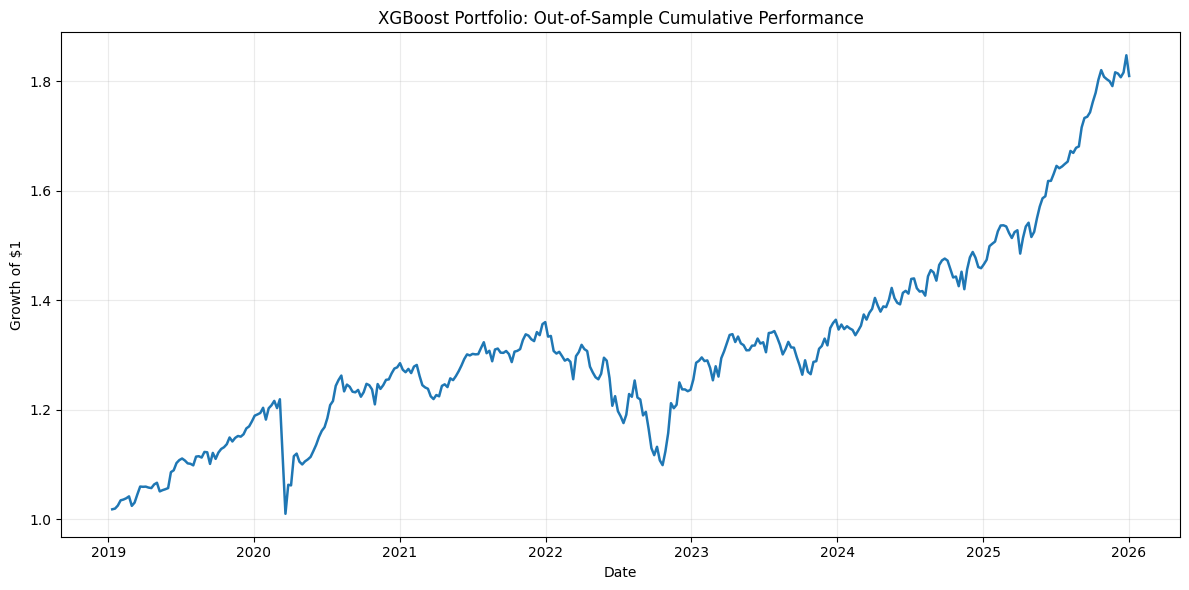

In [ ]:
xgb_cumulative = (
    1 + ml_portfolio_returns["XGBoost_Portfolio"].dropna()
).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(xgb_cumulative.index, xgb_cumulative.values, linewidth=1.8)
ax.set_title("XGBoost Portfolio: Out-of-Sample Cumulative Performance")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(
    BASE / "outputs" / "figures" / "xgb_cumulative_performance.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## 14.2 XGBoost Portfolio Drawdown

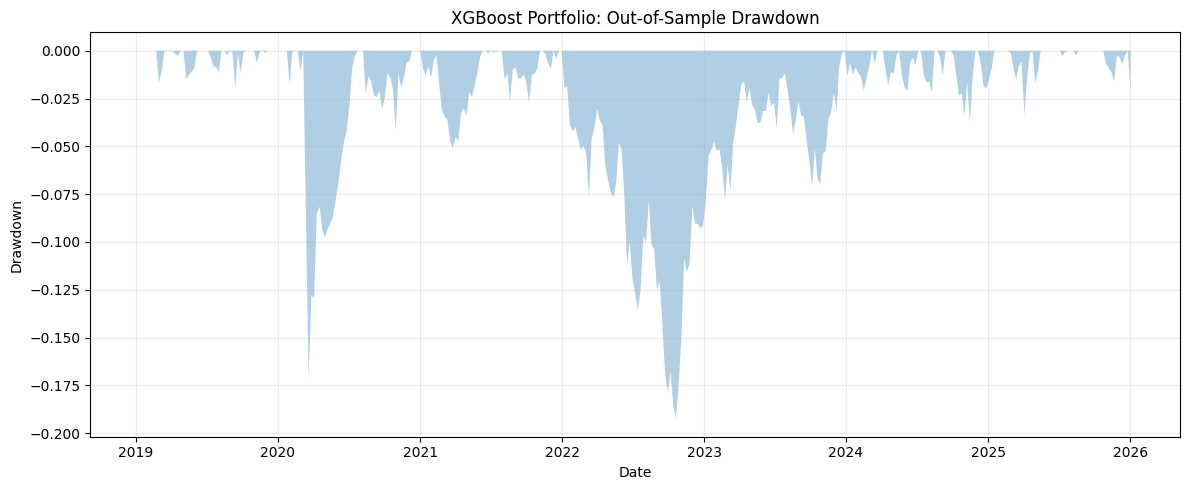

In [ ]:
xgb_wealth = (1 + ml_portfolio_returns["XGBoost_Portfolio"].dropna()).cumprod()
xgb_drawdown = xgb_wealth / xgb_wealth.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(xgb_drawdown.index, xgb_drawdown.values, 0, alpha=0.35)
ax.set_title("XGBoost Portfolio: Out-of-Sample Drawdown")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(
    BASE / "outputs" / "figures" / "xgb_drawdown.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## 14.3 XGBoost Forecast Accuracy by Asset

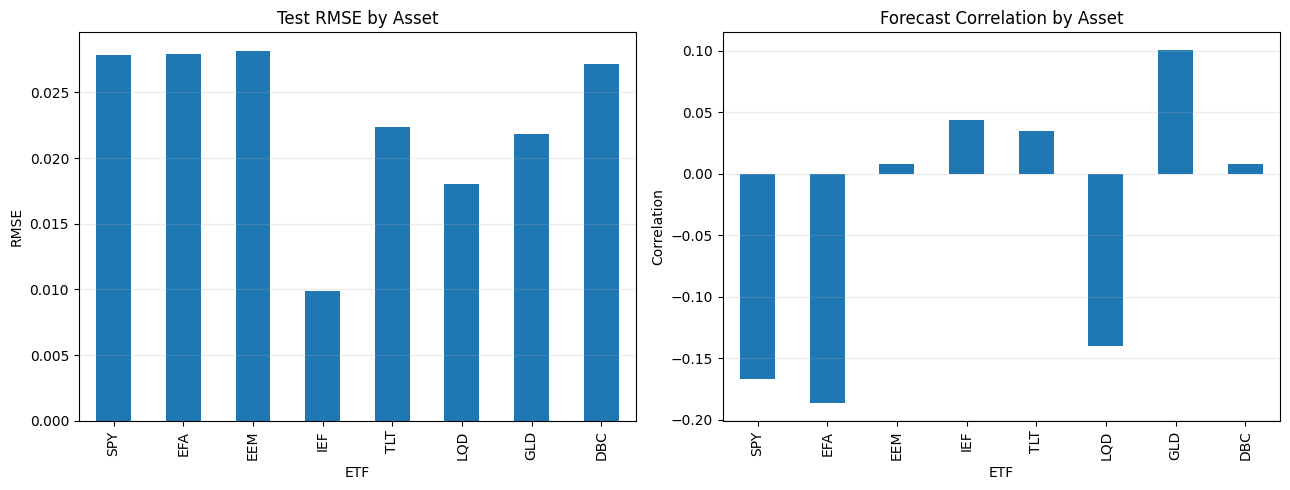

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

forecast_metrics["RMSE"].plot(kind="bar", ax=axes[0], title="Test RMSE by Asset")
axes[0].set_ylabel("RMSE")
axes[0].set_xlabel("ETF")
axes[0].grid(axis="y", alpha=0.25)

forecast_metrics["Correlation"].plot(kind="bar", ax=axes[1], title="Forecast Correlation by Asset")
axes[1].set_ylabel("Correlation")
axes[1].set_xlabel("ETF")
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(
    BASE / "outputs" / "figures" / "xgb_forecast_accuracy.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

## 14.4 XGBoost Portfolio Weights

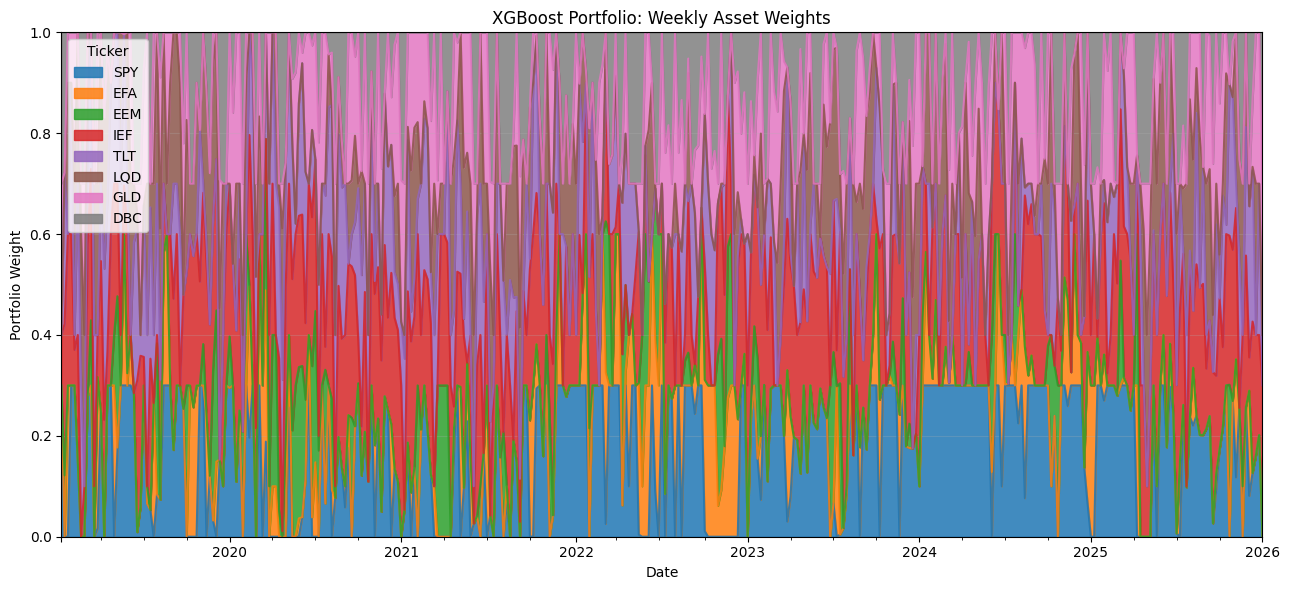

In [ ]:
weight_pivot = ml_portfolio_weights.pivot(
    index="Return_Date",
    columns="Ticker",
    values="Weight"
).reindex(columns=TICKERS)

fig, ax = plt.subplots(figsize=(13, 6))
weight_pivot.plot.area(ax=ax, stacked=True, alpha=0.85)
ax.set_title("XGBoost Portfolio: Weekly Asset Weights")
ax.set_ylabel("Portfolio Weight")
ax.set_xlabel("Date")
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(
    BASE / "outputs" / "figures" / "xgb_portfolio_weights.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

# 15. Benchmark Portfolios

The XGBoost portfolio is compared with three benchmarks that do not use machine-learning forecasts: **Equal Weight**, **Mean-Variance** (long-only minimum variance) and **Risk Parity** (inverse volatility). All three follow the same rules as the XGBoost portfolio: fully invested, long-only and a 30% maximum weight per ETF.

## 15.1 Equal Weight

In [ ]:
def equal_weight():
    return pd.Series(1 / len(TICKERS), index=TICKERS)

## 15.2 Mean-Variance Benchmark

The long-only minimum-variance portfolio, which uses the covariance matrix only and no return forecasts.

In [ ]:
def minimum_variance_weights(cov, max_weight=MAX_WEIGHT):
    w = cp.Variable(len(cov))

    objective = cp.Minimize(cp.quad_form(w, cov.values))
    constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]
    cp.Problem(objective, constraints).solve(solver=cp.CLARABEL)

    
    weights = np.clip(w.value, 0, max_weight)
    return pd.Series(weights / weights.sum(), index=cov.columns)

## 15.3 Risk-Parity Benchmark


In [ ]:
def inverse_volatility_weights(cov, max_weight=MAX_WEIGHT):
    inv_vol = 1 / np.sqrt(np.diag(cov.values))
    w = pd.Series(inv_vol / inv_vol.sum(), index=cov.columns)

    for _ in range(20):
        over = w > max_weight
        if not over.any():
            break

        excess = (w[over] - max_weight).sum()
        w[over] = max_weight
        w[~over] += excess * w[~over] / w[~over].sum()

    return w / w.sum()

# 16. Benchmark Walk-Forward Backtest

To make the comparison fair, the benchmarks use exactly the same weekly decision dates, information dates and holding periods as the XGBoost portfolio, so all four portfolios are evaluated over the same out-of-sample window. Each benchmark is estimated from the trailing 252 trading days of daily returns available at the decision date.

## 16.1 Weekly Benchmark Weights

In [ ]:
schedule = ml_portfolio_weights[["Decision_Date", "Feature_Date", "Return_Date"]].drop_duplicates()

benchmark_weight_frames = []

for decision_date, feature_date, return_date in schedule.itertuples(index=False):
    hist = daily_returns.loc[:feature_date, TICKERS].tail(LOOKBACK_DAYS)
    cov = hist.cov() * 252

    weights = {
        "Equal_Weight": equal_weight(),
        "Mean_Variance": minimum_variance_weights(cov),
        "Risk_Parity": inverse_volatility_weights(cov),
    }

    for name, w in weights.items():
        benchmark_weight_frames.append(pd.DataFrame({
            "Decision_Date": decision_date,
            "Feature_Date": feature_date,
            "Return_Date": return_date,
            "Portfolio": name,
            "Ticker": w.index,
            "Weight": w.values,
        }))

benchmark_weights = pd.concat(benchmark_weight_frames, ignore_index=True)

display(benchmark_weights.head())

,Decision_Date,Feature_Date,Return_Date,Portfolio,Ticker,Weight
0,2019-01-04,2019-01-04,2019-01-11,Equal_Weight,SPY,0.125
1,2019-01-04,2019-01-04,2019-01-11,Equal_Weight,EFA,0.125
2,2019-01-04,2019-01-04,2019-01-11,Equal_Weight,EEM,0.125
3,2019-01-04,2019-01-04,2019-01-11,Equal_Weight,IEF,0.125
4,2019-01-04,2019-01-04,2019-01-11,Equal_Weight,TLT,0.125


## 16.2 Benchmark Portfolio Returns

In [ ]:
benchmark_returns = {}

for name, group in benchmark_weights.groupby("Portfolio"):
    w = group.pivot(index="Return_Date", columns="Ticker", values="Weight").reindex(columns=TICKERS)
    r = weekly_returns.reindex(index=w.index, columns=TICKERS)
    benchmark_returns[name] = (w * r).sum(axis=1)

benchmark_returns = pd.DataFrame(benchmark_returns)
benchmark_returns.index.name = "Date"

display(benchmark_returns.head())

,Equal_Weight,Mean_Variance,Risk_Parity
Date,,,
2019-01-11,0.012382,0.004853,0.006646
2019-01-18,0.007593,0.000486,0.002324
2019-01-25,0.006099,0.006379,0.006314
2019-02-01,0.009932,0.008977,0.009041
2019-02-08,-0.002052,0.001975,0.001007


## 16.3 Save Benchmark Outputs

In [ ]:
benchmark_returns.to_csv(BASE / "outputs" / "benchmarks" / "benchmark_weekly_returns.csv")
benchmark_weights.to_csv(BASE / "outputs" / "benchmarks" / "benchmark_weights.csv", index=False)

# 17. Benchmark Plots

## 17.1 Benchmark Cumulative Performance

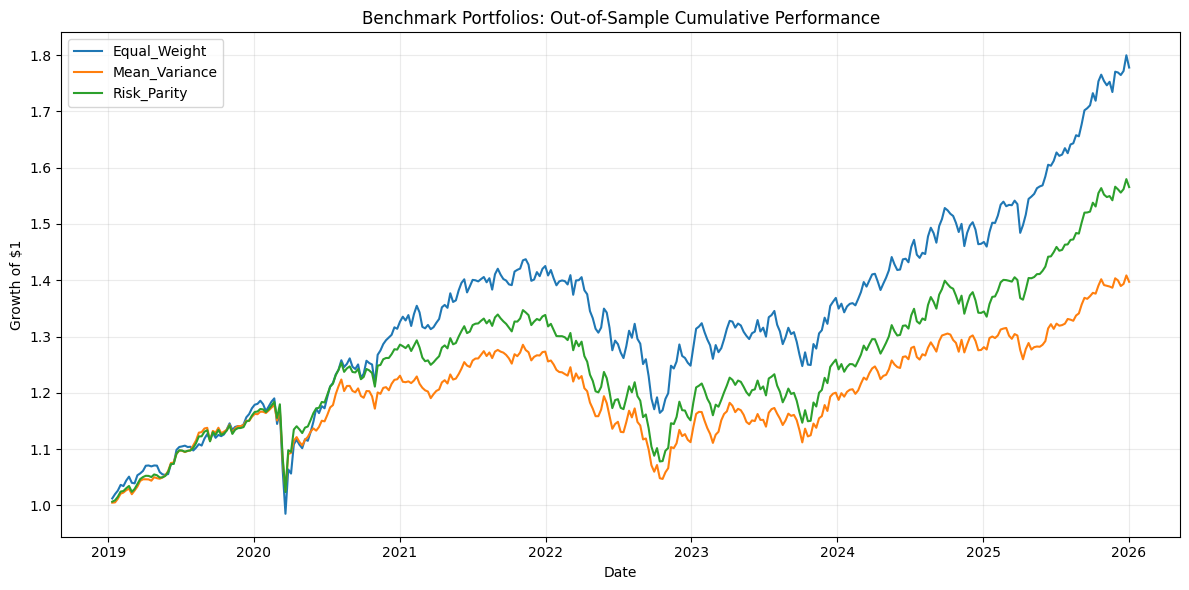

In [ ]:
PORTFOLIO_COLORS = {
    "XGBoost_Portfolio": "black",
    "Equal_Weight": "tab:blue",
    "Mean_Variance": "tab:orange",
    "Risk_Parity": "tab:green",
}

benchmark_cumulative = (1 + benchmark_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for name in benchmark_cumulative:
    ax.plot(benchmark_cumulative.index, benchmark_cumulative[name], label=name, color=PORTFOLIO_COLORS[name])
ax.set_title("Benchmark Portfolios: Out-of-Sample Cumulative Performance")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "outputs" / "figures" / "benchmark_cumulative_performance.png", dpi=150, bbox_inches="tight")
plt.show()

# 18. XGBoost vs Benchmarks

All four portfolios are evaluated on the same weekly out-of-sample returns, with the same metrics.

## 18.1 Performance Comparison

In [ ]:
comparison_returns = ml_portfolio_returns.join(benchmark_returns)
comparison_metrics = comparison_returns.apply(performance_metrics).T

display(comparison_metrics.sort_values("Sharpe_Ratio", ascending=False).round(4))

comparison_metrics.to_csv(BASE / "outputs" / "benchmarks" / "xgb_vs_benchmark_performance_metrics.csv")

,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Sortino_Ratio,Maximum_Drawdown,Historical_CVaR_95_Weekly
XGBoost_Portfolio,0.0882,0.1008,0.8752,1.0227,-0.1922,0.0314
Equal_Weight,0.0854,0.1009,0.8467,1.0579,-0.1899,0.0310
Risk_Parity,0.0659,0.0873,0.7555,0.9466,-0.1996,0.0264
Mean_Variance,0.0488,0.0790,0.6178,0.7706,-0.1854,0.0244


## 18.2 Cumulative Performance Comparison

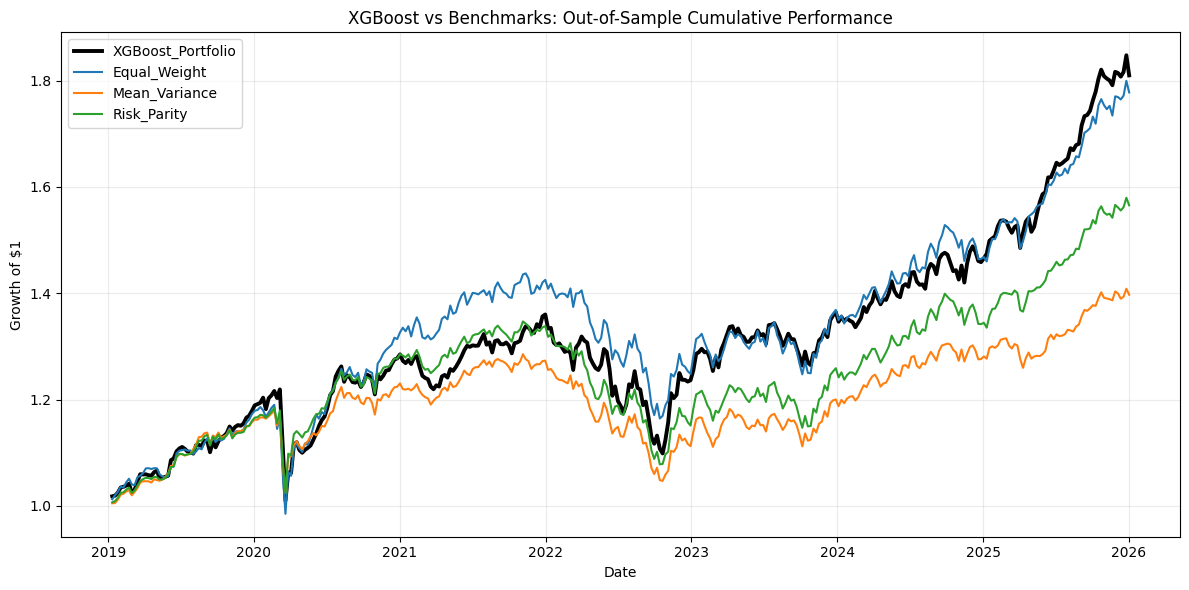

In [ ]:
comparison_cumulative = (1 + comparison_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for name in comparison_cumulative:
    ax.plot(
        comparison_cumulative.index,
        comparison_cumulative[name],
        label=name,
        color=PORTFOLIO_COLORS[name],
        linewidth=2.8 if name == "XGBoost_Portfolio" else 1.5,
    )
ax.set_title("XGBoost vs Benchmarks: Out-of-Sample Cumulative Performance")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "outputs" / "figures" / "xgb_vs_benchmarks_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()

## 18.3 Drawdown Comparison

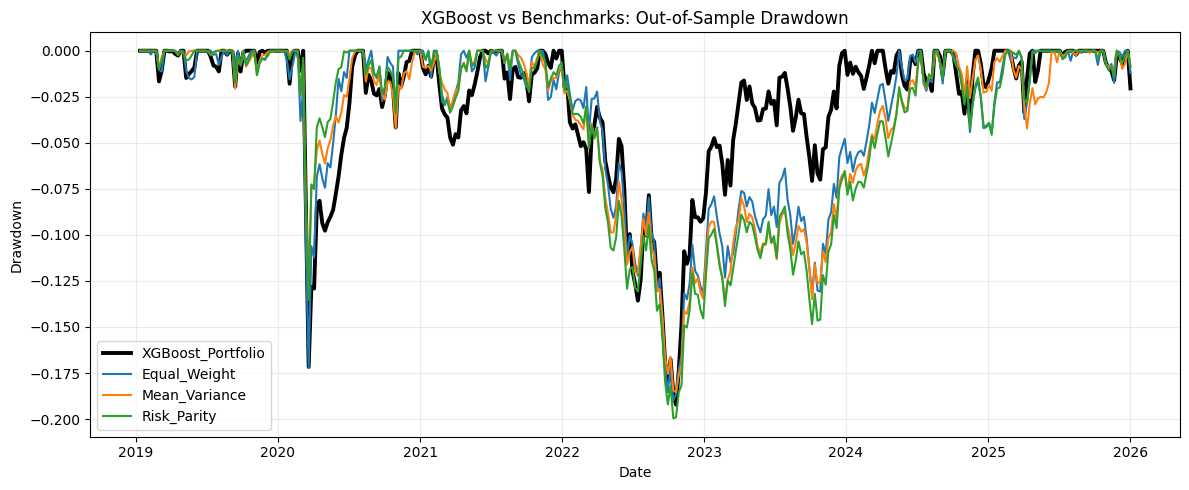

In [ ]:
comparison_drawdown = comparison_cumulative / comparison_cumulative.cummax() - 1

fig, ax = plt.subplots(figsize=(12, 5))
for name in comparison_drawdown:
    ax.plot(
        comparison_drawdown.index,
        comparison_drawdown[name],
        label=name,
        color=PORTFOLIO_COLORS[name],
        linewidth=2.8 if name == "XGBoost_Portfolio" else 1.5,
    )
ax.set_title("XGBoost vs Benchmarks: Out-of-Sample Drawdown")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(BASE / "outputs" / "figures" / "xgb_vs_benchmarks_drawdown.png", dpi=150, bbox_inches="tight")
plt.show()

## 18.4 Performance Metrics Comparison

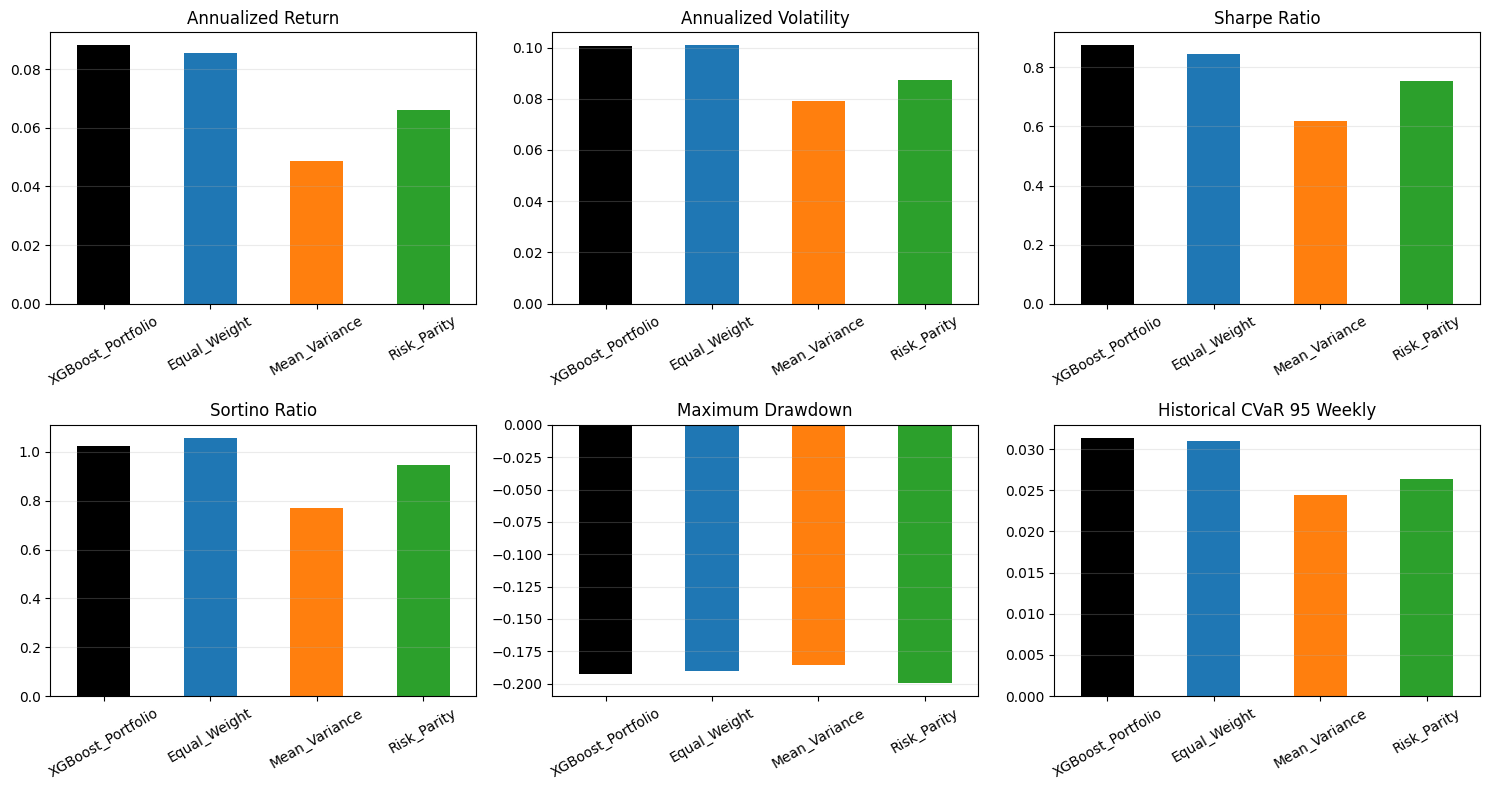

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, metric in zip(axes.flat, comparison_metrics.columns):
    comparison_metrics[metric].plot.bar(
        ax=ax, color=[PORTFOLIO_COLORS[name] for name in comparison_metrics.index]
    )
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig(BASE / "outputs" / "figures" / "xgb_vs_benchmarks_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# 19. XGBoost and Benchmark Data and Output Checks

In [ ]:
checks = pd.DataFrame({
    "Dataset": [
        "Adjusted Close",
        "Daily Returns",
        "5-Day Forward Returns",
        "Weekly Prices",
        "Weekly Returns",
        "XGBoost Forecasts",
        "XGBoost Portfolio Returns",
        "XGBoost Portfolio Weights",
        "Benchmark Portfolio Returns",
        "Benchmark Portfolio Weights"
    ],
    "Rows": [
        len(prices_aligned),
        len(daily_returns),
        len(forward_5d_returns),
        len(weekly_prices),
        len(weekly_returns),
        len(xgb_forecasts),
        len(ml_portfolio_returns),
        len(ml_portfolio_weights),
        len(benchmark_returns),
        len(benchmark_weights)
    ]
})

display(checks)

checks.to_csv(
    BASE / "outputs" / "benchmarks" / "xgb_data_checks.csv",
    index=False
)

,Dataset,Rows
0,Adjusted Close,4024
1,Daily Returns,4023
2,5-Day Forward Returns,4024
3,Weekly Prices,835
4,Weekly Returns,834
5,XGBoost Forecasts,365
6,XGBoost Portfolio Returns,365
7,XGBoost Portfolio Weights,2920
8,Benchmark Portfolio Returns,365
9,Benchmark Portfolio Weights,8760


# 20. Files Produced

### Processed data
- `data/raw/yahoo_etf_raw.csv`
- `data/processed/adjusted_close.csv`
- `data/processed/volume.csv`
- `data/processed/daily_returns.csv`
- `data/processed/log_returns.csv`
- `data/processed/forward_5d_returns.csv`
- `data/processed/weekly_prices.csv`
- `data/processed/weekly_returns.csv`
- `data/processed/modelling_calendar.csv`

### XGBoost outputs
- `outputs/benchmarks/xgb_validation_metrics.csv`
- `outputs/benchmarks/xgb_test_forecasts.csv`
- `outputs/benchmarks/xgb_test_actual_returns.csv`
- `outputs/benchmarks/xgb_test_forecast_metadata.csv`
- `outputs/benchmarks/xgb_test_forecast_metrics.csv`
- `outputs/benchmarks/xgb_portfolio_returns.csv`
- `outputs/benchmarks/xgb_portfolio_weights.csv`
- `outputs/benchmarks/xgb_portfolio_performance_metrics.csv`

### Benchmark outputs
- `outputs/benchmarks/benchmark_weekly_returns.csv`
- `outputs/benchmarks/benchmark_weights.csv`
- `outputs/benchmarks/xgb_vs_benchmark_performance_metrics.csv`

### XGBoost figures
- `outputs/figures/xgb_cumulative_performance.png`
- `outputs/figures/xgb_drawdown.png`
- `outputs/figures/xgb_forecast_accuracy.png`
- `outputs/figures/xgb_portfolio_weights.png`

### Benchmark and comparison figures
- `outputs/figures/benchmark_cumulative_performance.png`
- `outputs/figures/benchmark_weights.png`
- `outputs/figures/xgb_vs_benchmarks_cumulative.png`
- `outputs/figures/xgb_vs_benchmarks_drawdown.png`
- `outputs/figures/xgb_vs_benchmarks_metrics.png`